# 01 — Data Exploration

## Project Goal

This notebook explores Seattle 911 dispatch data to better understand traffic-related emergency call behavior and investigate whether environmental conditions may influence traffic call volume.

### Objectives
- Explore raw 911 call structure
- Identify relevant traffic-related event groups
- Investigate temporal patterns
- Detect anomalies and operational spikes
- Create a clean daily traffic dataset for downstream modeling


In [1]:
import pandas as pd
from pathlib import Path

# folder containing your CSVs
data_path = Path("../data/raw/911_calls")

# grab all csv files
csv_files = list(data_path.glob("*.csv"))

# load and combine
dfs = []

for file in csv_files:
    print(f"Loading {file.name}")
    df = pd.read_csv(file, low_memory=False)
    dfs.append(df)

calls = pd.concat(dfs, ignore_index=True)

# inspect
print(calls.shape)

calls.head()

Loading Call_Data_2024.csv
Loading Call_Data_2025.csv
Loading Call_Data_2026.csv
(1340940, 47)


,CAD Event Number,CAD Event Clearance Description,Call Type,Priority,Initial Call Type,Final Call Type,CAD Event Original Time Queued,CAD Event Arrived Time,Dispatch Precinct,Dispatch Sector,...,Call Sign Response Time (s),Call Sign at Scene Time,CAD Event First Response Time (s),Call Sign In-Service Time,Call Type Indicator,Dispatch Neighborhood,Call Type Received Classification,Dispatch Address,Count Of Officers,Event Group
0,2024000000001,ASSISTANCE RENDERED,ONVIEW,9,ASSIGNED DUTY - MEET W/ SUPERVISOR (OUT OF SVC),DOWN TIME - OUT OF SERVICE,01/01/2024 12:00:04 AM,2024 Jan 01 12:00:04 AM,SOUTH,ROBERT,...,0,2024 Jan 01 12:00:04 AM,0,2024 Jan 01 12:45:49 AM,ONVIEW,-,OFFICER_GENERATED,-,1,Administrative
1,2023000375305,ASSISTANCE RENDERED,911,1,UNKNOWN - ANI/ALI - WRLS PHNS (INCL OPEN LINE),"ASSIST PUBLIC - 911 HANG UP, OPEN LINE",01/01/2024 12:00:15 AM,2024 Jan 01 12:18:09 AM,WEST,DAVID,...,"1,074",2024 Jan 01 12:18:09 AM,"1,074",2024 Jan 01 04:49:47 AM,DISPATCH,EASTLAKE - WEST,COMMUNITY_GENERATED,19XX BLOCK OF YALE PL E,1,Assist Public
2,2023000375305,ASSISTANCE RENDERED,911,1,UNKNOWN - ANI/ALI - WRLS PHNS (INCL OPEN LINE),"ASSIST PUBLIC - 911 HANG UP, OPEN LINE",01/01/2024 12:00:15 AM,2024 Jan 01 12:18:09 AM,WEST,DAVID,...,NaN,NaN,"1,074",2024 Jan 01 12:13:03 AM,DISPATCH,EASTLAKE - WEST,COMMUNITY_GENERATED,19XX BLOCK OF YALE PL E,2,Assist Public
3,2024000000002,ASSISTANCE RENDERED,ONVIEW,3,DISTURBANCE,DISTURBANCE - OTHER,01/01/2024 12:00:58 AM,2024 Jan 01 12:00:58 AM,WEST,QUEEN,...,NaN,NaN,0,2024 Jan 01 12:09:32 AM,ONVIEW,QUEEN ANNE,OFFICER_GENERATED,2XX BLOCK OF THOMAS ST,2,Disturbance
4,2024000000002,ASSISTANCE RENDERED,ONVIEW,3,DISTURBANCE,DISTURBANCE - OTHER,01/01/2024 12:00:58 AM,2024 Jan 01 12:00:58 AM,WEST,QUEEN,...,0,2024 Jan 01 12:00:58 AM,0,2024 Jan 01 12:09:30 AM,ONVIEW,QUEEN ANNE,OFFICER_GENERATED,2XX BLOCK OF THOMAS ST,2,Disturbance


In [2]:
calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340940 entries, 0 to 1340939
Data columns (total 47 columns):
 #   Column                                               Non-Null Count    Dtype  
---  ------                                               --------------    -----  
 0   CAD Event Number                                     1340940 non-null  int64  
 1   CAD Event Clearance Description                      1340940 non-null  object 
 2   Call Type                                            1340940 non-null  object 
 3   Priority                                             1340940 non-null  int64  
 4   Initial Call Type                                    1340940 non-null  object 
 5   Final Call Type                                      1340940 non-null  object 
 6   CAD Event Original Time Queued                       1340940 non-null  object 
 7   CAD Event Arrived Time                               1239704 non-null  object 
 8   Dispatch Precinct                         

In [3]:
calls.columns.tolist()

['CAD Event Number',
 'CAD Event Clearance Description',
 'Call Type',
 'Priority',
 'Initial Call Type',
 'Final Call Type',
 'CAD Event Original Time Queued',
 'CAD Event Arrived Time',
 'Dispatch Precinct',
 'Dispatch Sector',
 'Dispatch Beat',
 'Dispatch Longitude',
 'Dispatch Latitude',
 'Dispatch Reporting Area',
 'CAD Event Response Category',
 'Call Sign Dispatch ID',
 'Call Sign Dispatch Time',
 'First CARE Call Sign At Scene Time',
 'First CARE Call Sign Dispatch Time',
 'First Co-Response Call Sign At Scene Time',
 'First Co-Response Call Sign Dispatch Time',
 'First SPD Call Sign at Scene Time',
 'First SPD Call Sign Dispatch Time',
 'Last CARE Call Sign In-Service Time',
 'Last Co-Response Call Sign In-Service Time',
 'Last SPD Call Sign In-Service Time',
 'CARE Call Sign Total Service Time (s)',
 'Co-Response Call Sign Total Service Time (s)',
 'SPD Call Sign Total Service Time (s)',
 'Call Sign Total Service Time (s)',
 'First CARE Call Sign Dispatch Delay Time (s)',
 'F

In [4]:
columns_to_keep = [
    'CAD Event Number',
    'CAD Event Original Time Queued',
    'Call Type',
    'Priority',
    'Final Call Type',
    'Dispatch Latitude',
    'Dispatch Longitude',
    'Dispatch Neighborhood',
    'CAD Event First Response Time (s)',
    'Event Group'
]

calls = calls[columns_to_keep]

calls.head()

,CAD Event Number,CAD Event Original Time Queued,Call Type,Priority,Final Call Type,Dispatch Latitude,Dispatch Longitude,Dispatch Neighborhood,CAD Event First Response Time (s),Event Group
0,2024000000001,01/01/2024 12:00:04 AM,ONVIEW,9,DOWN TIME - OUT OF SERVICE,-1.00000000,-1.00000000,-,0,Administrative
1,2023000375305,01/01/2024 12:00:15 AM,911,1,"ASSIST PUBLIC - 911 HANG UP, OPEN LINE",47.63612753,-122.32628200,EASTLAKE - WEST,"1,074",Assist Public
2,2023000375305,01/01/2024 12:00:15 AM,911,1,"ASSIST PUBLIC - 911 HANG UP, OPEN LINE",47.63612753,-122.32628200,EASTLAKE - WEST,"1,074",Assist Public
3,2024000000002,01/01/2024 12:00:58 AM,ONVIEW,3,DISTURBANCE - OTHER,47.62092404,-122.35216831,QUEEN ANNE,0,Disturbance
4,2024000000002,01/01/2024 12:00:58 AM,ONVIEW,3,DISTURBANCE - OTHER,47.62092404,-122.35216831,QUEEN ANNE,0,Disturbance


In [5]:
calls['CAD Event Original Time Queued'] = pd.to_datetime(
    calls['CAD Event Original Time Queued']
)

/var/folders/qy/w1846_ms6g97cvq51vdv9qrr0000gn/T/ipykernel_53579/3107562393.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  calls['CAD Event Original Time Queued'] = pd.to_datetime(


In [6]:
calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340940 entries, 0 to 1340939
Data columns (total 10 columns):
 #   Column                             Non-Null Count    Dtype         
---  ------                             --------------    -----         
 0   CAD Event Number                   1340940 non-null  int64         
 1   CAD Event Original Time Queued     1340940 non-null  datetime64[ns]
 2   Call Type                          1340940 non-null  object        
 3   Priority                           1340940 non-null  int64         
 4   Final Call Type                    1340940 non-null  object        
 5   Dispatch Latitude                  1340940 non-null  object        
 6   Dispatch Longitude                 1340940 non-null  object        
 7   Dispatch Neighborhood              1340210 non-null  object        
 8   CAD Event First Response Time (s)  1239704 non-null  object        
 9   Event Group                        1340940 non-null  object        
dtypes: dat

In [7]:
calls['year'] = calls['CAD Event Original Time Queued'].dt.year
calls['month'] = calls['CAD Event Original Time Queued'].dt.month
calls['day'] = calls['CAD Event Original Time Queued'].dt.day
calls['hour'] = calls['CAD Event Original Time Queued'].dt.hour
calls['day_of_week'] = calls['CAD Event Original Time Queued'].dt.day_name()
calls['weekend'] = calls['day_of_week'].isin(['Saturday', 'Sunday'])
calls["date"] = (
    calls["CAD Event Original Time Queued"]
    .dt.date
)

In [8]:
calls.head()

,CAD Event Number,CAD Event Original Time Queued,Call Type,Priority,Final Call Type,Dispatch Latitude,Dispatch Longitude,Dispatch Neighborhood,CAD Event First Response Time (s),Event Group,year,month,day,hour,day_of_week,weekend,date
0,2024000000001,2024-01-01 00:00:04,ONVIEW,9,DOWN TIME - OUT OF SERVICE,-1.00000000,-1.00000000,-,0,Administrative,2024,1,1,0,Monday,False,2024-01-01
1,2023000375305,2024-01-01 00:00:15,911,1,"ASSIST PUBLIC - 911 HANG UP, OPEN LINE",47.63612753,-122.32628200,EASTLAKE - WEST,"1,074",Assist Public,2024,1,1,0,Monday,False,2024-01-01
2,2023000375305,2024-01-01 00:00:15,911,1,"ASSIST PUBLIC - 911 HANG UP, OPEN LINE",47.63612753,-122.32628200,EASTLAKE - WEST,"1,074",Assist Public,2024,1,1,0,Monday,False,2024-01-01
3,2024000000002,2024-01-01 00:00:58,ONVIEW,3,DISTURBANCE - OTHER,47.62092404,-122.35216831,QUEEN ANNE,0,Disturbance,2024,1,1,0,Monday,False,2024-01-01
4,2024000000002,2024-01-01 00:00:58,ONVIEW,3,DISTURBANCE - OTHER,47.62092404,-122.35216831,QUEEN ANNE,0,Disturbance,2024,1,1,0,Monday,False,2024-01-01


In [9]:
daily_calls = (
    calls
    .groupby(
        calls['CAD Event Original Time Queued'].dt.date
    )
    .size()
    .reset_index(name='call_volume')
)

daily_calls = daily_calls.rename(
    columns={'CAD Event Original Time Queued': 'date'}
)

daily_calls.head()

,date,call_volume
0,2024-01-01,1500
1,2024-01-02,1380
2,2024-01-03,1589
3,2024-01-04,1570
4,2024-01-05,1511


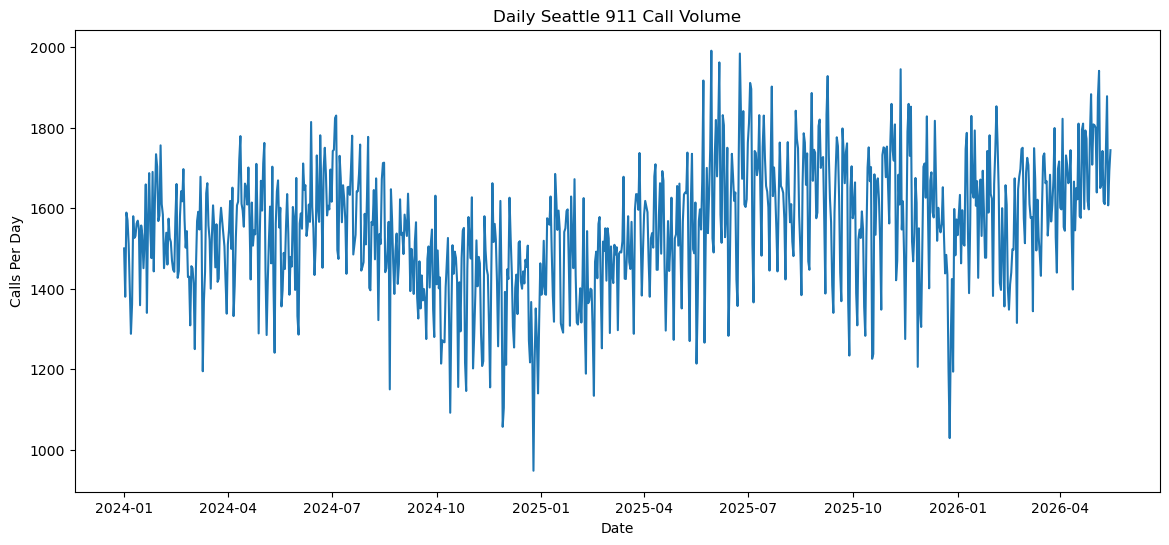

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(
    daily_calls['date'],
    daily_calls['call_volume']
)

plt.title("Daily Seattle 911 Call Volume")
plt.xlabel("Date")
plt.ylabel("Calls Per Day")

plt.savefig("../outputs/daily_seattle_911_volume.png")

plt.show()

In [57]:
weekday_calls = (
    calls
    .groupby('day_of_week')
    .size()
    .reset_index(name='call_volume')
)

weekday_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

weekday_calls['day_of_week'] = pd.Categorical(
    weekday_calls['day_of_week'],
    categories=weekday_order,
    ordered=True
)

weekday_calls = weekday_calls.sort_values('day_of_week')

weekday_calls

,day_of_week,call_volume
1,Monday,194039
5,Tuesday,200411
6,Wednesday,195122
4,Thursday,196777
0,Friday,203576
2,Saturday,180524
3,Sunday,170491


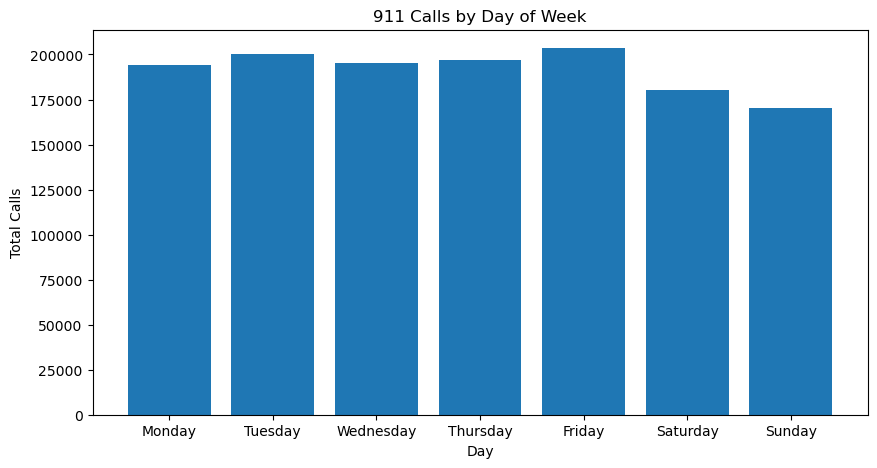

In [58]:
plt.figure(figsize=(10,5))

plt.bar(
    weekday_calls['day_of_week'],
    weekday_calls['call_volume']
)

plt.title("911 Calls by Day of Week")
plt.xlabel("Day")
plt.ylabel("Total Calls")

plt.show()

In [59]:
calls['Event Group'].value_counts().head(15)

Event Group
Disturbance                      161011
Traffic                          158111
Suspicious Circumstances         154856
Assist Public                    104997
Domestic Disturbance/Violence     71745
Crisis Complaint                  70339
Assaults                          69312
Assist Other Agency               60529
Prowler                           56244
Theft                             49089
Premise Checks                    48653
Automobiles                       46179
Directed Patrol                   30914
Burglary                          28773
Narcotics                         21948
Name: count, dtype: int64

In [60]:
traffic_calls = calls[
    calls['Event Group'] == 'Traffic'
]

daily_traffic = (
    traffic_calls
    .groupby(
        traffic_calls['CAD Event Original Time Queued'].dt.date
    )
    .size()
    .reset_index(name='traffic_calls')
)

daily_traffic = daily_traffic.rename(
    columns={'CAD Event Original Time Queued': 'date'}
)

daily_traffic.head()

,date,traffic_calls
0,2024-01-01,119
1,2024-01-02,138
2,2024-01-03,134
3,2024-01-04,140
4,2024-01-05,178


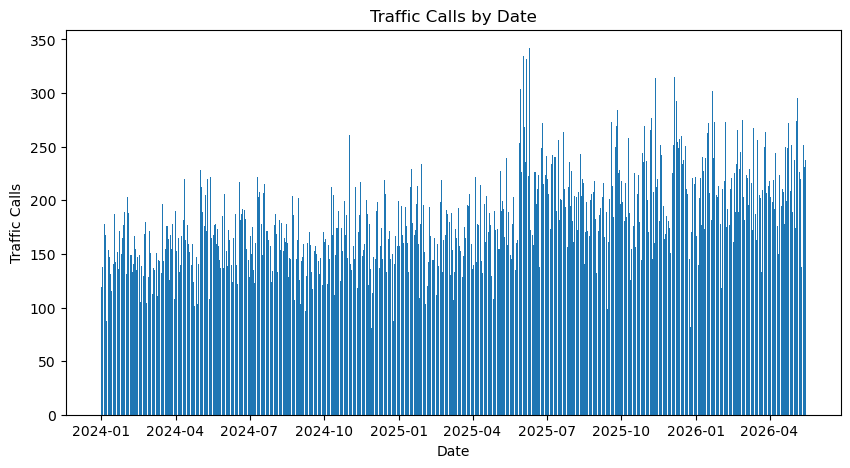

In [61]:
plt.figure(figsize=(10,5))

plt.bar(
    daily_traffic['date'],
    daily_traffic['traffic_calls']
)

plt.title("Traffic Calls by Date")
plt.xlabel("Date")
plt.ylabel("Traffic Calls")

plt.show()

In [62]:
top_days = daily_traffic.sort_values(
    "traffic_calls",
    ascending=False
)[["date", "traffic_calls"]]

top_days.head(15)

,date,traffic_calls
526,2025-06-10,342
519,2025-06-03,335
522,2025-06-06,332
529,2025-06-13,331
704,2025-12-05,315
681,2025-11-12,314
840,2026-04-20,311
508,2025-05-23,308
712,2025-12-13,304
515,2025-05-30,304


In [63]:
daily_event_groups = (
    traffic_calls
    .groupby(
        [
            "date",
            "Final Call Type"
        ]
    )
    .size()
    .reset_index(name="count")
)

In [64]:
event_group_baseline = (
    daily_event_groups
    .groupby("Final Call Type")["count"]
    .mean()
    .reset_index(name="avg_daily_count")
)

In [65]:
spike_comparison = daily_event_groups.merge(
    event_group_baseline,
    on="Final Call Type"
)

In [66]:
spike_comparison["difference"] = (
    spike_comparison["count"] -
    spike_comparison["avg_daily_count"]
)

spike_comparison["pct_above_avg"] = (
    spike_comparison["difference"] /
    spike_comparison["avg_daily_count"]
) * 100

In [67]:
top_dates = top_days["date"].tolist()

spike_analysis = spike_comparison[
    spike_comparison["date"].isin(top_dates)
]

In [71]:
spike_analysis = spike_analysis.merge(
    top_days,
    on="date",
    how="left"
)

In [72]:
spike_analysis.sort_values(
    ["traffic_calls", "pct_above_avg"],
    ascending=[False, False]
).head(50)

,date,Final Call Type,count,avg_daily_count,difference,pct_above_avg,traffic_calls
4897,2025-06-10,TRAFFIC - MOVING VIOLATION,152,46.726328,105.273672,225.298406,342
4894,2025-06-10,TRAFFIC - BLOCKING TRAFFIC,13,6.148061,6.851939,111.448777,342
4895,2025-06-10,TRAFFIC - COMMUNITY TRAFFIC COMPLAINT (CTC),8,4.135635,3.864365,93.440668,342
4900,2025-06-10,TRAFFIC - PEDESTRIAN VIOLATION,4,2.124224,1.875776,88.304094,342
4898,2025-06-10,TRAFFIC - MV COLLISION INVESTIGATION,79,51.483834,27.516166,53.446226,342
4896,2025-06-10,TRAFFIC - D.U.I.,22,15.678487,6.321513,40.319662,342
4899,2025-06-10,TRAFFIC - PARKING VIOL (EXCEPT ABANDONED CAR),62,50.784065,11.215935,22.085541,342
4901,2025-06-10,TRAFFIC STOP - OFFICER INITIATED ONVIEW,1,1.856354,-0.856354,-46.130952,342
4893,2025-06-10,TRAFFIC - ASSIST MOTORIST,1,2.938040,-1.938040,-65.963708,342
4829,2025-06-03,TRAFFIC - MOVING VIOLATION,166,46.726328,119.273672,255.260101,335


In [73]:
moving = (
    traffic_calls[
        traffic_calls["Final Call Type"] == "TRAFFIC - MOVING VIOLATION"
    ]
    .groupby("date")
    .size()
    .reset_index(name="count")
)

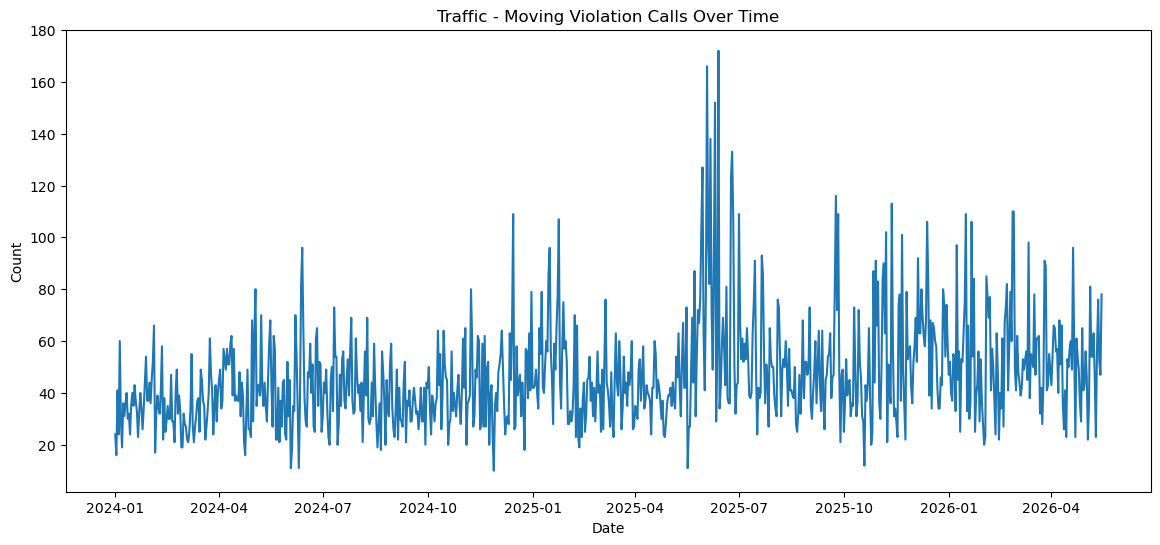

In [74]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(
    moving["date"],
    moving["count"]
)

plt.title("Traffic - Moving Violation Calls Over Time")
plt.xlabel("Date")
plt.ylabel("Count")

plt.show()

“A series of anomalous June 2025 traffic-call spikes were initially suspected to be weather-related. Deeper decomposition revealed that the spikes were primarily driven by moving-violation calls rather than collision-related incidents. Further time-series inspection showed the surge was temporary rather than structural, suggesting a short-lived enforcement or operational activity period rather than a lasting change in traffic conditions.”

In [32]:
calls.groupby(
    calls["date"].apply(lambda x: x.strftime("%Y-%m"))
).size()

date
2024-01    47366
2024-02    44338
2024-03    46342
2024-04    47160
2024-05    47170
2024-06    47884
2024-07    50120
2024-08    47362
2024-09    43776
2024-10    43061
2024-11    41913
2024-12    42346
2025-01    46271
2025-02    39439
2025-03    46368
2025-04    45967
2025-05    48661
2025-06    49734
2025-07    51983
2025-08    50802
2025-09    49063
2025-10    48431
2025-11    48120
2025-12    47457
2026-01    49889
2026-02    43800
2026-03    49944
2026-04    50175
2026-05    25998
dtype: int64

In [16]:
calls.to_csv(
    '../data/processed/cleaned_911_calls.csv',
    index=False
)

In [17]:
calls["date"] = pd.to_datetime(
    calls["CAD Event Original Time Queued"]
).dt.date

daily_calls = (
    calls
    .groupby("date")
    .size()
    .reset_index(name="total_calls")
)

daily_calls

,date,total_calls
0,2024-01-01,1500
1,2024-01-02,1380
2,2024-01-03,1589
3,2024-01-04,1570
4,2024-01-05,1511
...,...,...
861,2026-05-11,1740
862,2026-05-12,1878
863,2026-05-13,1607
864,2026-05-14,1692


In [18]:
daily_calls.to_csv("../data/processed/daily_911_calls.csv", index=False)